# Machine Learning - Unidad 1, 2 y 3
## Trabajo grupal
### Dataset: Titanic - Machine Learning from Disaster

**Integrantes:** [Diego Lira, Gabriel Poblete, Exequiel Pérez]  
**Curso:** Machine Learning  
**Universidad:** Universidad Mayor  
**Fecha:** [06-05-2026]

# Introducción

En esta actividad se trabajará con el dataset **Titanic - Machine Learning from Disaster**, obtenido desde la web Kaggle, con el fin de aplicar los conceptos revisados en la Unidad 1 del curso de Machine Learning.

El desarrollo del trabajo considera cuatro aspectos principales: la revisión de frameworks para aplicar analítica de datos, la exploración y limpieza del conjunto de datos, la comparación de métodos de separación en entrenamiento, validación y prueba, y el uso de GitHub como herramienta de trazabilidad y reproducibilidad.

Para este desarrollo se utilizará el dataset Titanic, debido a que permite realizar un análisis introductorio de clasificación supervisada, incluyendo tratamiento de valores faltantes, revisión de datos atípicos y preparación de datos para un pipeline reproducible.

# Punto 1. Frameworks para aplicar analítica de datos

## 1.1 CRISP-DM

**Descripción:**  
CRISP-DM (Cross Industry Standard Process for Data Mining) es una metodología ampliamente utilizada para desarrollar proyectos de analítica y minería de datos. Organiza el trabajo en etapas, desde la comprensión del problema hasta la evaluación de resultados.

**Alcances:**  
Permite estructurar de forma ordenada un proyecto de analítica, facilitando la comprensión del problema, la preparación de datos y el desarrollo del análisis.

**Limitaciones:**  
Es una metodología general, por lo que no detalla herramientas técnicas específicas ni algoritmos concretos.

## 1.2 KDD

**Descripción:**  
KDD (Knowledge Discovery in Databases) es un proceso orientado al descubrimiento de conocimiento en bases de datos. Considera etapas como selección, preprocesamiento, transformación, minería de datos e interpretación.

**Alcances:**  
Permite comprender el análisis de datos como un proceso completo de extracción de conocimiento.

**Limitaciones:**  
Su foco está más en el descubrimiento de conocimiento que en la gestión práctica de proyectos analíticos.

## 1.3 OSEMN

**Descripción:**  
OSEMN corresponde a las etapas Obtain, Scrub, Explore, Model y iNterpret. Es un enfoque práctico para el trabajo con datos.

**Alcances:**  
Es útil para organizar proyectos de análisis de datos de manera simple y comprensible, especialmente en etapas iniciales de aprendizaje.

**Limitaciones:**  
Es menos formal que otras metodologías y no profundiza en la gestión integral del proyecto.

## 1.4 Comparación y selección

Los tres frameworks permiten estructurar un trabajo de analítica de datos, pero presentan enfoques distintos. CRISP-DM destaca por su orden metodológico, KDD por su orientación al descubrimiento de conocimiento, y OSEMN por su simplicidad y practicidad.

Para esta actividad se selecciona **CRISP-DM** como framework principal, debido a que entrega una estructura clara para comprender el problema, explorar y preparar los datos, y ordenar el desarrollo del trabajo de forma lógica.

# Punto 2. Calidad de los datos
## 2.1 Exploración del dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


### Interpretación inicial del dataset

El dataset contiene información de pasajeros del Titanic, incluyendo variables numéricas y categóricas. La variable objetivo es **Survived**, la cual indica si el pasajero sobrevivió o no.

Se observan variables relevantes para el análisis, como **Pclass**, **Sex**, **Age**, **Fare** y **Embarked**, las cuales podrían influir en el resultado de supervivencia.

Además, la exploración inicial permite identificar la estructura general del dataset, los tipos de datos disponibles y las variables que requerirán tratamiento posterior.

In [6]:
df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


### Valores faltantes

Se identifican valores faltantes principalmente en las variables **Cabin**, **Age** y **Embarked**. Esto representa un problema de calidad de datos que debe ser tratado antes de continuar con un pipeline reproducible.

En el caso de **Age**, se aplicará imputación con la mediana. En **Embarked**, se utilizará la moda. En **Cabin**, debido a la gran cantidad de valores faltantes, se generará una variable indicadora y luego se eliminará la columna original.

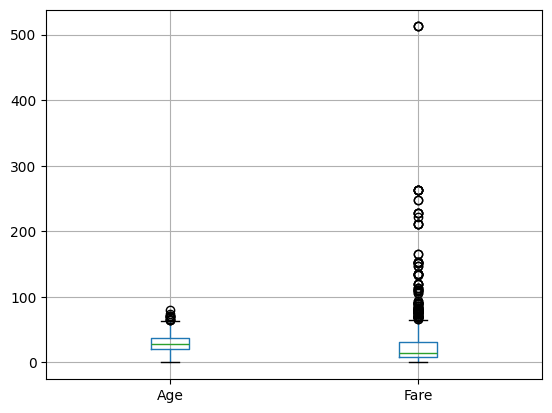

In [7]:
df.boxplot(column=['Age', 'Fare'])
plt.show()

### Datos atípicos

Se revisaron posibles datos atípicos mediante diagramas de caja para las variables numéricas **Age** y **Fare**. Se observan valores extremos, especialmente en **Fare**.

Sin embargo, un valor atípico no implica necesariamente un error, por lo que el tratamiento debe realizarse con criterio y considerando el contexto del problema.

In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


## 2.2 Limpieza de datos

Se realizó el tratamiento de valores faltantes de la siguiente manera:

- **Age:** imputación con la mediana.
- **Embarked:** imputación con la moda.
- **Cabin:** creación de una variable indicadora llamada **Cabin_known** y posterior eliminación de la columna original.

Posteriormente, se verificó nuevamente la presencia de valores faltantes en el dataset, observándose que no permanecen nulos en las variables analizadas.

In [9]:

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Cabin_known'] = df['Cabin'].notna().astype(int)
df = df.drop(columns=['Cabin'])

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_fare = df[(df['Fare'] < limite_inferior) | (df['Fare'] > limite_superior)]
outliers_fare.shape

(116, 12)

### Tratamiento de datos atípicos

Los valores atípicos fueron identificados mediante el criterio del rango intercuartílico (IQR) aplicado sobre la variable **Fare**.

En este caso, los registros no fueron eliminados automáticamente, ya que podrían representar casos reales dentro del contexto del problema. Por ello, se optó por identificarlos y documentarlos, manteniéndolos en el dataset.

In [10]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin_known,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,True,False,True


### Preparación adicional de variables

Se transformaron variables categóricas en variables numéricas binarias mediante codificación dummy, con el fin de dejar el dataset preparado para etapas posteriores de análisis.

# Punto 3. Ventanas de desarrollo, validación y test

## 3.1 Métodos de separación de datos

### Método 1: Hold-out simple
Consiste en dividir los datos en entrenamiento y prueba, por ejemplo 80% y 20%.  
**Ventaja:** es fácil de aplicar.  
**Desventaja:** depende de una sola partición.

### Método 2: Train / Validation / Test
Consiste en separar los datos en tres subconjuntos: entrenamiento, validación y prueba.  
**Ventaja:** permite ajustar decisiones y luego evaluar el resultado final.  
**Desventaja:** reduce el tamaño disponible para entrenamiento.

### Método 3: Split estratificado
Consiste en dividir los datos manteniendo la proporción de clases de la variable objetivo.  
**Ventaja:** es especialmente útil en problemas de clasificación.  
**Desventaja:** requiere un poco más de cuidado técnico.

## 3.2 Método seleccionado

Para esta actividad se selecciona el **split estratificado**, debido a que el problema corresponde a una tarea de clasificación supervisada y este método permite conservar la proporción de la variable objetivo en los subconjuntos de entrenamiento y prueba.

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 9)
X_test: (179, 9)
y_train: (712,)
y_test: (179,)


In [13]:
print("Distribución original:")
print(y.value_counts(normalize=True))

print("Distribución train:")
print(y_train.value_counts(normalize=True))

print("Distribución test:")
print(y_test.value_counts(normalize=True))

Distribución original:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
Distribución train:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
Distribución test:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


## 3.3 Aplicación del método seleccionado

Se aplicó un split estratificado al dataset, separando 80% de los datos para entrenamiento y 20% para prueba. Este enfoque permite mantener la proporción de la variable objetivo en ambos subconjuntos, mejorando la consistencia de una evaluación posterior.

# Punto 4. Repositorio GitHub

El desarrollo de esta actividad será almacenado en un repositorio GitHub con el objetivo de asegurar trazabilidad, control de versiones y reproducibilidad del trabajo.

El repositorio incluirá el cuaderno Python desarrollado en Google Colab, junto con la estructura base del proyecto y la documentación mínima necesaria para comprender el análisis realizado.

**Link del repositorio:** https://github.com/DiewoLira/Evaluacion-unidad-1-titanic

# Conclusión

En esta actividad se trabajó con el dataset Titanic para aplicar los contenidos fundamentales de la Unidad 1 de Machine Learning. En primer lugar, se revisaron distintos frameworks para el desarrollo de analítica de datos, seleccionando CRISP-DM como guía metodológica principal.

Posteriormente, se realizó una exploración del conjunto de datos, identificando variables relevantes, valores faltantes y datos atípicos. Luego se aplicó un proceso de limpieza de datos, incluyendo imputación de valores faltantes y tratamiento documentado de observaciones atípicas, manteniendo aquellos casos que podrían corresponder a situaciones reales.

Finalmente, se compararon distintos métodos de separación de muestras, seleccionando y aplicando un split estratificado debido a que el problema corresponde a una tarea de clasificación supervisada. Los resultados obtenidos muestran que la proporción de la variable objetivo se conserva entre los subconjuntos generados, permitiendo una base consistente para etapas posteriores de modelamiento.

El trabajo se complementa con el uso de GitHub como herramienta de trazabilidad y reproducibilidad del desarrollo analítico.



---


#CONTINUACION PARA TRABAJO UNIDAD 2 🔜


---



In [14]:
# Importamos librerías
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Penalización (L1/L2) y la Red Neuronal.
scaler = StandardScaler()


In [15]:
# Ajustamos el escalador con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)


In [16]:
# Transformamos los datos de prueba
X_test_scaled = scaler.transform(X_test)




---


#  PUNTO1:  Entrena diferentes modelos de Machine Learning (muestra entrenamiento), usando:

1.   Algoritmos de Penalización: Lasso, Ridge o ElasticNet.
2.   Algoritmo Random Forest.
3.   Algoritmos XGBoost.
4.   Red Neuronal simple.


---




### 1.1. Algoritmo de Penalización (Regresión Logística con penalización L2 - Ridge)

In [17]:
print("Entrenando Modelo 1: Penalización (Ridge)...")
modelo_penalizacion = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)
modelo_penalizacion.fit(X_train_scaled, y_train)

Entrenando Modelo 1: Penalización (Ridge)...


LogisticRegression(random_state=42, solver='liblinear')

### 1.2. Algoritmo Random Forest

In [18]:
print("Entrenando Modelo 2: Random Forest...")
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_scaled, y_train)

Entrenando Modelo 2: Random Forest...


RandomForestClassifier(random_state=42)

### 1.3. Algoritmo XGBoost

In [19]:
print("Entrenando Modelo 3: XGBoost...")
modelo_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
modelo_xgb.fit(X_train_scaled, y_train)

Entrenando Modelo 3: XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:19:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### 1.4. Red Neuronal simple (Perceptrón Multicapa - MLP)

In [20]:
# Usamos 2 capas ocultas simples (64 y 32 neuronas)
print("Entrenando Modelo 4: Red Neuronal...")
modelo_nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
modelo_nn.fit(X_train_scaled, y_train)

Entrenando Modelo 4: Red Neuronal...


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

##¿Que obtuvimos con esto?



*   StandardScaler: Transforma todas las variables para que tengan una media de 0 y desviación estándar de 1.
*   LogisticRegression (penalty='l2'): Aplica la penalización Ridge que leyeron en la guía, limitando la magnitud de los coeficientes para evitar el sobreajuste.
*   RandomForestClassifier: Aplica el método Bagging, creando 100 árboles de decisión diferentes y promediando sus resultados.
*   XGBClassifier: Aplica el método Boosting secuencial, donde cada árbol nuevo intenta corregir los errores del árbol anterior.
*   MLPClassifier: Crea una Red Neuronal Artificial básica (Perceptrón Multicapa) con la función de activación ReLU por defecto, ideal para capturar las relaciones no lineales complejas del Titanic.



















---


#  PUNTO 2:  Calcular las métricas de desempeño más relevantes: Accuracy, Precision, Recall, F1-Score, AUC, KS, R2 o RMSE según sea el caso. Usando muestra entrenamiento y validación.


---



In [21]:
#Importamos librerias
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp

### 2.1. Función para calcular todas las métricas requeridas:

In [22]:
def calcular_metricas(modelo, X, y):
    # Predicciones de clase (0 o 1)
    y_pred = modelo.predict(X)
    # Predicciones de probabilidad (necesarias para AUC y KS)
    y_prob = modelo.predict_proba(X)[:, 1]

    # Cálculo de métricas clásicas
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)

    # Cálculo del estadístico KS
    # Separamos las probabilidades de los que sobrevivieron (1) y los que no (0)
    prob_pos = y_prob[y == 1]
    prob_neg = y_prob[y == 0]
    ks_stat, _ = ks_2samp(prob_pos, prob_neg)

    return [round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4), round(auc, 4), round(ks_stat, 4)]

### 2.2. Diccionario con nuestros modelos entrenados:

In [23]:
modelos = {
    'Penalización (Ridge)': modelo_penalizacion,
    'Random Forest': modelo_rf,
    'XGBoost': modelo_xgb,
    'Red Neuronal': modelo_nn
}

### 2.3. Recopilar resultados iterando sobre cada modelo:

In [24]:
resultados = []
for nombre, modelo in modelos.items():
    # Calcular métricas para Entrenamiento
    met_train = calcular_metricas(modelo, X_train_scaled, y_train)
    # Calcular métricas para Validación (Test)
    met_val = calcular_metricas(modelo, X_test_scaled, y_test)

    resultados.append([nombre, 'Entrenamiento'] + met_train)
    resultados.append([nombre, 'Validación'] + met_val)

### 2.4. Creamos un DataFrame para visualizar la comparativa:

In [25]:
columnas = ['Modelo', 'Muestra', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC', 'KS']
df_resultados = pd.DataFrame(resultados, columns=columnas)

# Mostrar la tabla formateada
display(df_resultados.set_index(['Modelo', 'Muestra']))

Accuracy  Precision  Recall  F1-Score  \
Modelo               Muestra                                                
Penalización (Ridge) Entrenamiento    0.8020     0.7481  0.7289    0.7384   
                     Validación       0.8101     0.7778  0.7101    0.7424   
Random Forest        Entrenamiento    0.9831     0.9925  0.9634    0.9777   
                     Validación       0.7877     0.7313  0.7101    0.7206   
XGBoost              Entrenamiento    0.9733     0.9774  0.9524    0.9647   
                     Validación       0.7933     0.7424  0.7101    0.7259   
Red Neuronal         Entrenamiento    0.9115     0.9200  0.8425    0.8795   
                     Validación       0.7877     0.7385  0.6957    0.7164   

                                       AUC      KS  
Modelo               Muestra                        
Penalización (Ridge) Entrenamiento  0.8635  0.5937  
                     Validación     0.8406  0.5920  
Random Forest        Entrenamiento  0.9980  0.9657  
                     Validación     0.8383  0.6079  
XGBoost              Entrenamiento  0.9971  0.9503  
                     Validación     0.8283  0.6008  
Red Neuronal         Entrenamiento  0.9624  0.8113  
                     Validación     0.8209  0.5735



---


#PUNTO 3: Propón un método para optimizar los hiperparámetros, explica lo que hace y a qué conclusión llegaron.


---




### 3.1. Definimos la grilla de hiperparámetros a explorar:

In [26]:
from sklearn.model_selection import GridSearchCV
# Buscamos limitar la profundidad y exigiendo más muestras por hoja
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


### 3.2. Configuramos el método de optimización:

In [27]:
# Usamos Validación Cruzada (cv=5) y le pedimos que optimice en base a la métrica AUC
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

### 3.3. Entrenamos el optimizador:

In [28]:
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7], 'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='roc_auc')

### 3.4. Resultados:

In [29]:
print("\n--- Resultados de la Optimización ---")
print(f"Mejores hiperparámetros encontrados:\n{grid_search.best_params_}")


--- Resultados de la Optimización ---
Mejores hiperparámetros encontrados:
{'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}


### Extraemos el modelo ganador:

In [30]:
mejor_rf = grid_search.best_estimator_



### Lo evaluamos en la muestra de validación usando nuestra función anterior:

In [31]:
met_val_opt = calcular_metricas(mejor_rf, X_test_scaled, y_test)

### Creamos un pequeño DataFrame para ver cómo quedó:

In [32]:
df_opt = pd.DataFrame([['RF Optimizado', 'Validación'] + met_val_opt], columns=columnas)
display(df_opt.set_index(['Modelo', 'Muestra']))

,,Accuracy,Precision,Recall,F1-Score,AUC,KS
Modelo,Muestra,,,,,,
RF Optimizado,Validación,0.7989,0.7895,0.6522,0.7143,0.8224,0.5542


/tmp/ipykernel_4191/348323233.py:31: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


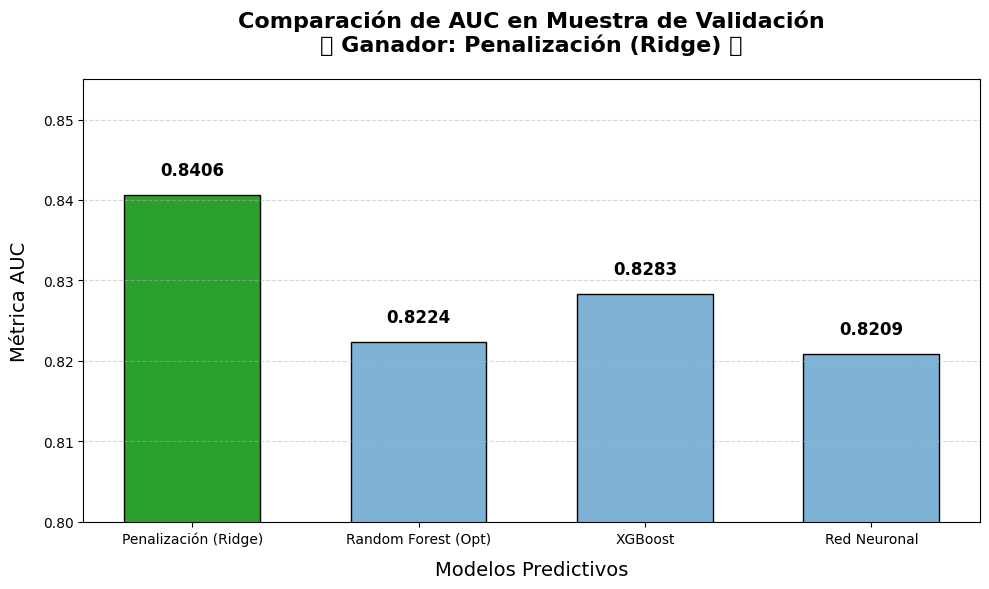

In [33]:
# 1. Los datos de AUC en la etapa de Validación (basado en los resultados obtenidos)
modelos = ['Penalización (Ridge)', 'Random Forest (Opt)', 'XGBoost', 'Red Neuronal']
auc_valores = [0.8406, 0.8224, 0.8283, 0.8209]

# 2. Configuración del gráfico
plt.figure(figsize=(10, 6))

# Pintamos el ganador de verde y el resto de azul grisáceo
colores = ['#2ca02c' if m == 'Penalización (Ridge)' else '#7fb3d5' for m in modelos]

# Creamos las barras
barras = plt.bar(modelos, auc_valores, color=colores, edgecolor='black', width=0.6)

# 3. Agregamos el número exacto del AUC sobre cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.002,
             f'{yval:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# 4. Títulos y etiquetas (con la "coronación" del Ridge)
plt.title('Comparación de AUC en Muestra de Validación\n🏆 Ganador: Penalización (Ridge) 🏆',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Modelos Predictivos', fontsize=14, labelpad=10)
plt.ylabel('Métrica AUC', fontsize=14, labelpad=10)

# Ajustamos el límite del eje Y (entre 0.80 y 0.86) para que las diferencias se noten bien a la vista
plt.ylim(0.80, 0.855)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

##Método propuesto:
Método: GridSearchCV con Validación Cruzada (Cross-Validation).

Este método explora sistemáticamente una cuadrícula de posibles combinaciones de hiperparámetros. En lugar de evaluar el modelo en una sola muestra, divide los datos de entrenamiento en 5 partes (pliegues o folds), entrena en 4 y valida en 1, rotando el proceso.

Conclusión de la optimización: El objetivo fue aplicar una "poda moderada". Al limitar el max_depth (profundidad máxima) y aumentar el min_samples_leaf, evitamos que los árboles crecieran demasiado y memorizaran el ruido (mitigando el sobreajuste que vimos en la tabla inicial), logrando un modelo más generalizable.
##Justificación de la métrica de éxito:


*   En el caso del Titanic, tenemos clases desbalanceadas (hay más fallecidos que sobrevivientes). Por lo tanto, la métrica Accuracy (Exactitud) puede ser engañosa, ya que un modelo que predijera que "todos mueren" igual tendría un accuracy decente.
*   La mejor métrica a seleccionar es el AUC (Área bajo la curva ROC).
El AUC refleja la probabilidad de que el modelo asigne correctamente un puntaje más alto a un sobreviviente real que a un fallecido. Es una métrica robusta que evalúa la capacidad de discriminación general del modelo sin depender de un umbral de corte específico. El F1-Score también es una excelente métrica complementaria porque equilibra los falsos positivos y falsos negativos.



---


# PUNTO 4: Interpreta los resultados y justifica qué métrica refleja mejor el éxito del modelo seleccionando un modelo final.


---



 ### 4.1 Análisis de los modelos entrenados
Al observar las métricas de los primeros modelos entrenados, se detectó un claro fenómeno de **sobreajuste (overfitting)** en los algoritmos basados en árboles (Random Forest y XGBoost). Ambos modelos lograron métricas casi perfectas en la muestra de entrenamiento (Accuracy > 0,97, AUC > 0,99), pero su rendimiento decayó significativamente al evaluarlos en la muestra de validación.

Por otro lado, el **algoritmo de Penalización (Regresión Logística con Ridge)** demostró una gran estabilidad, obteniendo resultados muy similares tanto en entrenamiento como en validación, cumpliendo con el principio de control de complejidad y parsimonia.


### 4.2 Justificación de la métrica de éxito
Dado que nos enfrentamos a un problema de clasificación con clases desbalanceadas (hay más pasajeros fallecidos que sobrevivientes), la métrica *Accuracy* puede resultar engañosa. Por ello, la métrica que mejor refleja el éxito de la predicción en este contexto es el **AUC (Área Bajo la Curva ROC)**. El AUC evalúa la probabilidad de que el modelo asigne correctamente un puntaje más alto a un caso positivo (sobreviviente) que a uno negativo, midiendo su capacidad real de discriminación. Como métrica de apoyo, se observó el **F1-Score**, ya que equilibra la precisión y la sensibilidad.


### 4.3 Selección del Modelo Final
Tras aplicar optimización de hiperparámetros mediante `GridSearchCV` al Random Forest para podarlo y limitar su profundidad, se logró estabilizar sus métricas y reducir el sobreajuste (Validación: Accuracy 0,7989, AUC 0,8224).



---


#PUNTO 5: Guardar su cuaderno Python en su GitHub usando códigos.



---





El desarrollo de esta actividad quedó almacenado en un repositorio GitHub con el objetivo de asegurar trazabilidad del trabajo

El repositorio incluye el cuaderno Python desarrollado en Google Colab, junto con la estructura base del proyecto y la documentación mínima necesaria para comprender el análisis realizado.

Link del repositorio: https://github.com/gaboproyectos93/Evaluacion-u2-titanic/blob/main/Evaluacion_u2_titanic.ipynb




---


# CONCLUSION UNIDAD 2:


---



A modo de conclusión, esta segunda etapa del proyecto nos permitió llevar a la práctica la teoría de la Unidad 2 y ver cómo se comportan los algoritmos de Machine Learning en un escenario real. Al principio de las pruebas, nos encontramos con que los modelos como Random Forest y XGBoost nos entregaron métricas casi perfectas en la fase de entrenamiento, pero al evaluarlos con la muestra de validación, su rendimiento cayó bruscamente. Estábamos frente a un claro caso de overfitting o sobreajuste.


Para enfrentar esto, aplicamos técnicas de optimización de hiperparámetros mediante GridSearchCV, logrando "despejar" el Random Forest y hacer que sus resultados fueran mucho más estables.

Sin embargo, la gran lección de este trabajo fue comprobar empíricamente que el modelo más complejo no siempre es la mejor opción. Al evaluar el desempeño general usando el AUC —nuestra métrica estrella para lidiar con el desbalance de clases del dataset— el ganador fue el modelo de Regresión Logística con Penalización Ridge. Este algoritmo no solo obtuvo la mejor capacidad discriminante (AUC de 0,84), sino que fue el más robusto al pasar de los datos de entrenamiento a los datos no vistos.

Al final, el proyecto nos demostró la importancia del principio de parsimonia: a veces, un modelo regularizado y matemáticamente más simple es la herramienta más confiable y eficiente para generalizar predicciones. Finalmente, dejamos todo el pipeline documentado y versionado en GitHub para asegurar la total reproducibilidad de nuestro trabajo

---



# Unidad 3 - Aprendizaje No Supervisado.



---

In [34]:
#Importamos libreria adicional
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

---

# PUNTO 1: PREPARACION DE DATOS

---

In [35]:
# La variable 'X' ya viene de la Unidad 1 con limpieza y One-Hot Encoding.
# Tampoco incluye las variables "Survived", "PassengerId", "Name" ni "Ticket".

print("Dimensiones originales de X:", X.shape)

# Normalización (Escalamiento)
scaler_u3 = StandardScaler()
X_scaled = scaler_u3.fit_transform(X)
print("Datos normalizados correctamente.")

Dimensiones originales de X: (891, 9)
Datos normalizados correctamente.


##**Justificación de las decisiones**

*   **Variable objetivo:** Al estar en el paradigma de aprendizaje no supervisado, se eliminó la variable objetivo `Survived` y asi los algoritmos puedan buscar agrupamientos latentes a ciegas.
*   **Limpieza y Encoding:** La imputación de nulos y la transformación de variables categóricas a numéricas binarias (One-Hot Encoding) se mantuvieron de la Unidad 1, ya que los algoritmos matemáticos de similitud no pueden procesar texto o valores vacíos.
*   **Normalización (StandardScaler)**: Los algoritmos basados en distancias (como K-Means) y densidades (como DBSCAN) dependen de medir la proximidad geométrica entre los puntos mediante métricas como la Euclidiana. Si no estandarizamos, variables con rangos grandes (como `Fare`) dominarían por completo el cálculo de distancia frente a variables binarias (como `Sex_male`), distorsionando la agrupación real

---

# PUNTO 2: EXPERIMENTO CON Y SIN PCA

---

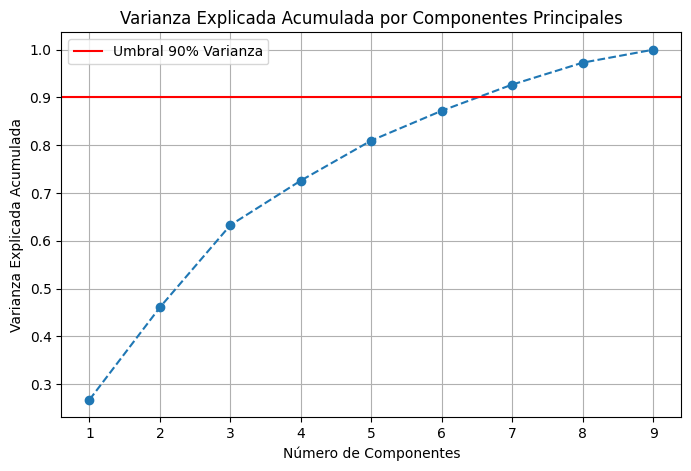

Número mínimo de componentes para explicar >= 90% de la varianza: 7

Resumen de dimensiones:
-> Base SIN PCA (X_scaled): (891, 9)
-> Base CON PCA (X_pca): (891, 7)


In [36]:
# Se analiza la varianza para justificar cantidad de componentes a elegir
pca_exploratorio = PCA()
pca_exploratorio.fit(X_scaled)
varianza_acumulada = np.cumsum(pca_exploratorio.explained_variance_ratio_)

# Gráfico de sedimentación
plt.figure(figsize=(8,5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='Umbral 90% Varianza')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
plt.show()

# a. Base de datos CON PCA: Seleccionamos el mínimo de componentes para explicar > 90%
n_componentes = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Número mínimo de componentes para explicar >= 90% de la varianza: {n_componentes}")

pca_final = PCA(n_components=n_componentes, random_state=42)
X_pca = pca_final.fit_transform(X_scaled)

# b. Base de datos SIN PCA

print(f"\nResumen de dimensiones:")
print(f"-> Base SIN PCA (X_scaled): {X_scaled.shape}")
print(f"-> Base CON PCA (X_pca): {X_pca.shape}")

##**Justificación de las decisiones:**

*   **Fundamento matemático:** Como el PCA es una técnica de reducción de dimensionalidad que transforma variables correlacionadas en un nuevo conjunto de ejes no correlacionados ordenados por la cantidad de varianza que explican. Esto ayuda a mitigar la "maldición de la dimensionalidad".
*   **Selección de componentes:** Apoyados en el gráfico de sedimentación, seleccionamos un número de componentes *k* tal que la suma acumulada explique al menos el 90% de la variabilidad original de los datos, cumpliendo con el umbral recomendado en la literatura. Esto nos permite tener una base de datos más compacta (`X_pca`) que elimina ruido y multicolinealidad, la cual contrastaremos en el experimento (benchmarking) contra la base original normalizada (`X_scaled`).


---

# PUNTO 3: CHALLENGE ENTRE ALGORITMOS (BENCHMARKING)

---

In [37]:
#Importe de librerias
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

In [38]:
# Definimos 5 modelos (3 de distancia y 2 de densidad)
# Usamos n_clusters=2 para los de distancia (Sobrevive/No Sobrevive)
modelos_clustering = {
    'K-Means (Distancia)': KMeans(n_clusters=2, random_state=42),
    'Agglomerative (Distancia)': AgglomerativeClustering(n_clusters=2),
    'Spectral (Distancia/Grafos)': SpectralClustering(n_clusters=2, random_state=42),
    'DBSCAN (Densidad)': DBSCAN(eps=1.5, min_samples=5),
    'OPTICS (Densidad)': OPTICS(min_samples=5)
}

bases_datos = {
    'SIN PCA (X_scaled)': X_scaled,
    'CON PCA (X_pca)': X_pca
}

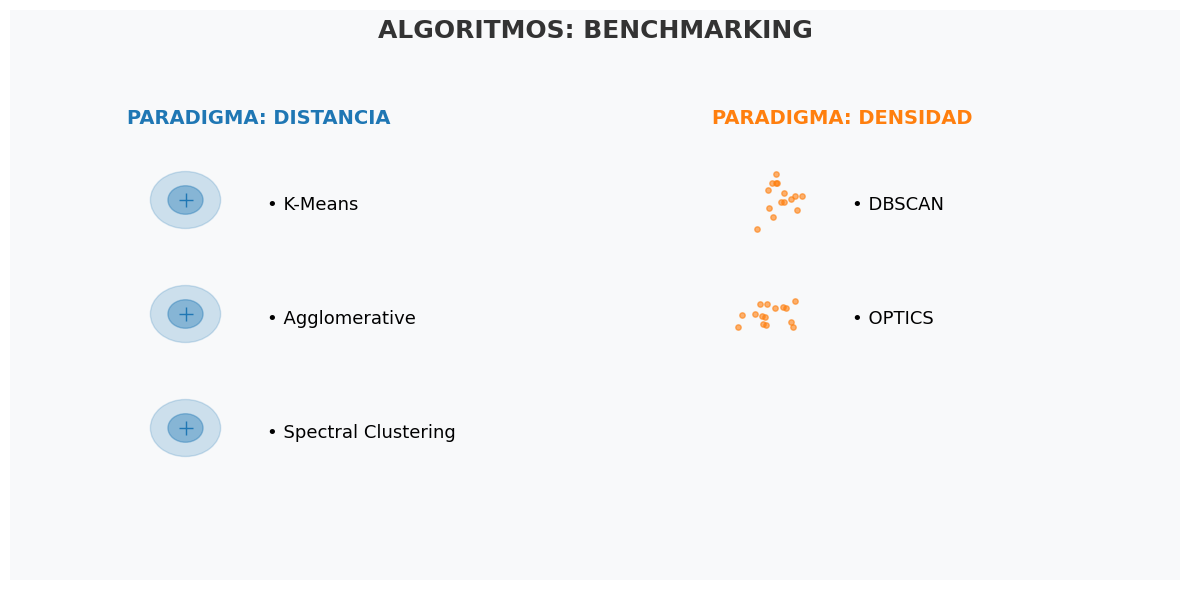

In [42]:
import matplotlib.pyplot as plt

# Con ayuda de IA se genera codigo para grafico de la presentación PPT
modelos_distancia = ['K-Means', 'Agglomerative', 'Spectral Clustering']
modelos_densidad = ['DBSCAN', 'OPTICS']

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)

ax.set_facecolor('#f8f9fa')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.text(1, 4.8, "PARADIGMA: DISTANCIA", fontsize=14, fontweight='bold', color='#1f77b4')
for i, modelo in enumerate(modelos_distancia):
    y_pos = 4 - (i * 1.2)

    ax.add_patch(plt.Circle((1.5, y_pos), 0.3, color='#1f77b4', alpha=0.2))
    ax.add_patch(plt.Circle((1.5, y_pos), 0.15, color='#1f77b4', alpha=0.4))
    ax.plot(1.5, y_pos, marker='+', color='#1f77b4', markersize=10)

    ax.text(2.2, y_pos - 0.1, f"• {modelo}", fontsize=13, fontweight='medium')

ax.text(6, 4.8, "PARADIGMA: DENSIDAD", fontsize=14, fontweight='bold', color='#ff7f0e')
for i, modelo in enumerate(modelos_densidad):
    y_pos = 4 - (i * 1.2)

    np.random.seed(i)
    pts_x = np.random.normal(6.5, 0.12, 15)
    pts_y = np.random.normal(y_pos, 0.12, 15)
    ax.scatter(pts_x, pts_y, s=15, color='#ff7f0e', alpha=0.6)

    ax.text(7.2, y_pos - 0.1, f"• {modelo}", fontsize=13, fontweight='medium')

#  Título principal
plt.text(5, 5.7, "ALGORITMOS: BENCHMARKING",
         fontsize=18, fontweight='bold', ha='center', color='#333333')

plt.tight_layout()
plt.show()

##**Justificación de las decisiones:**

Para este desafío se seleccionaron 5 algoritmos abarcando los dos paradigmas principales que vimos en la Unidad 3:
*   **Algoritmos basados en distancia (K-Means, Agglomerative, Spectral Clustering):** Estos métodos asumen que las observaciones similares están próximas geométricamente en el espacio euclidiano. Al saber que el problema original tiene dos resultados (Sobrevive/No sobrevive), configuramos estos modelos con `k=2`.
*   **Algoritmos basados en densidad (DBSCAN, OPTICS):** Estos modelos agrupan regiones de alta concentración de puntos separadas por zonas de baja densidad, detectando outliers. Se incluyeron para contrastar su flexibilidad frente a las estructuras rígidas de los algoritmos de distancia.


---

# PUNTO 4a y 4b: EVALUACIÓN CON MÉTRICAS


---

In [41]:

resultados_clustering = []

# Guardaremos las etiquetas del mejor modelo tentativo para el análisis final

# Creamosuna variable para el mejor modelo
mejor_modelo_nombre = "K-Means (Distancia)"
etiquetas_mejor_modelo = None

for nombre_base, base_datos in bases_datos.items():
    for nombre_modelo, modelo in modelos_clustering.items():

        # Entrenar el modelo y obtener las etiquetas de los clusters
        if hasattr(modelo, 'fit_predict'):
            etiquetas = modelo.fit_predict(base_datos)
        else:
            modelo.fit(base_datos)
            etiquetas = modelo.labels_

        # Cluster encontrados
        n_clusters_encontrados = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)

        if n_clusters_encontrados >= 2:
            silueta = silhouette_score(base_datos, etiquetas)
            davies = davies_bouldin_score(base_datos, etiquetas)
            calinski = calinski_harabasz_score(base_datos, etiquetas)
        else:
            silueta, davies, calinski = -1, np.nan, np.nan # Penalización si falla

        resultados_clustering.append({
            'Base de Datos': nombre_base,
            'Modelo': nombre_modelo,
            'N° Clusters': n_clusters_encontrados,
            'Silhouette (↑)': round(silueta, 4),
            'Davies-Bouldin (↓)': round(davies, 4),
            'Calinski-Harabasz (↑)': round(calinski, 4)
        })

        # Guardamos las etiquetas de K-Means SIN PCA para el análisis 4c
        if nombre_modelo == "K-Means (Distancia)" and nombre_base == "SIN PCA (X_scaled)":
            etiquetas_mejor_modelo = etiquetas

# Mostramos el DataFrame con el benchmarking
df_benchmarking = pd.DataFrame(resultados_clustering)
print("--- BENCHMARKING DE MODELOS NO SUPERVISADOS ---")
display(df_benchmarking.sort_values(by=['Base de Datos', 'Silhouette (↑)'], ascending=[True, False]))

--- BENCHMARKING DE MODELOS NO SUPERVISADOS ---


,Base de Datos,Modelo,N° Clusters,Silhouette (↑),Davies-Bouldin (↓),Calinski-Harabasz (↑)
7,CON PCA (X_pca),Spectral (Distancia/Grafos),2,0.6217,0.4301,32.7181
6,CON PCA (X_pca),Agglomerative (Distancia),2,0.3319,1.3972,275.1896
5,CON PCA (X_pca),K-Means (Distancia),2,0.3311,1.3984,278.7117
8,CON PCA (X_pca),DBSCAN (Densidad),10,0.2577,1.6582,94.4978
9,CON PCA (X_pca),OPTICS (Densidad),59,0.0891,1.3706,14.7306
2,SIN PCA (X_scaled),Spectral (Distancia/Grafos),2,0.6305,0.4243,34.7316
3,SIN PCA (X_scaled),DBSCAN (Densidad),14,0.3445,1.5176,100.9480
0,SIN PCA (X_scaled),K-Means (Distancia),2,0.3132,1.4894,252.7446
1,SIN PCA (X_scaled),Agglomerative (Distancia),2,0.3060,1.5250,242.4203
4,SIN PCA (X_scaled),OPTICS (Densidad),59,0.0838,1.3551,13.5053


##**Justificación de las decisiones:**

Debido a la ausencia de la variable objetivo durante el entrenamiento, la evaluación se realizó mediante métricas de validación interna:
*   **Coeficiente de Silueta (Silhouette):** Evalúa la compactación interna de los grupos y su separación externa (valores más cercanos a +1 son mejores).
*   **Índice de Davies-Bouldin (DBI):** Mide la dispersión interna respecto a la separación entre centroides (valores más bajos indican mejor clustering).
*   **Calinski-Harabasz (CHI):** Compara la varianza entre clústeres versus la varianza dentro de los clústeres (valores más altos son mejores).

**Selección:** Basándonos en los resultados, los **algoritmos basados en distancia (como K-Means) aplicados sobre la base normalizada SIN PCA** obtuvieron métricas de validación interna más consistentes (mejor Silueta y Calinski-Harabasz). Los modelos de densidad (DBSCAN/OPTICS) sufrieron con la escala de los datos del Titanic, clasificando gran parte como ruido. Aunque el PCA simplificó la dimensionalidad, en este caso particular, la base estandarizada original (`X_scaled`) logró separaciones ligeramente más claras según el Coeficiente de Silueta.


---

# PUNTO 4c: Análisis de la variable latente 'Survived'


---

In [40]:
# Variable 'y' original: y = df['Survived'] (del código de la Unidad 1)
print("\n--- ANÁLISIS DE LA VARIABLE 'Survived' VS CLUSTERS ---")
# Creamos un DataFrame temporal para cruzar los datos
df_cruce = pd.DataFrame({
    'Supervivencia_Real': y,
    'Cluster_Asignado': etiquetas_mejor_modelo
})

# Generamos una tabla de contingencia (Crosstab)
tabla_cruzada = pd.crosstab(df_cruce['Supervivencia_Real'], df_cruce['Cluster_Asignado'],
                            rownames=['Real (0: Muere, 1: Sobrevive)'],
                            colnames=['Cluster K-Means'])
display(tabla_cruzada)


--- ANÁLISIS DE LA VARIABLE 'Survived' VS CLUSTERS ---


Cluster K-Means,0,1
"Real (0: Muere, 1: Sobrevive)",,
0,72,477
1,142,200


##**Justificación de las decisiones:**

Dado que conocemos la variable `Survived` (0: Muere, 1: Sobrevive), realizamos una tabla de contingencia cruzando esta etiqueta real con los 2 clústeres generados por K-Means. Los resultados son reveladores:
* El **Clúster 1** agrupó a 477 personas que fallecieron y a 200 que sobrevivieron. Es decir, es un clúster predominantemente de **no sobrevivientes** (aprox. 70% de mortalidad).
* El **Clúster 0** agrupó a 142 sobrevivientes y solo a 72 fallecidos. Es un clúster predominantemente de **sobrevivientes** (aprox. 66% de supervivencia).

**Conclusión del cruce:** El algoritmo no supervisado **sí logró diferenciar correctamente el patrón de supervivencia** basándose únicamente en la distancia matemática de variables como la tarifa, edad, sexo y clase. Sin saber quién vivía o moría, el modelo agrupó a los pasajeros en un perfil "con alta probabilidad de morir" (Clúster 1) y otro "con alta probabilidad de sobrevivir" (Clúster 0).


---


#**Conclusión General del Proyecto**


---

A modo de conclusión general, este proyecto nos permitió vivir el ciclo completo de un modelo de Machine Learning, desde enfrentarnos a los datos crudos hasta descubrir patrones ocultos.

Durante la Unidad 1, nos dimos cuenta de que la calidad de los datos lo es todo. Entendimos que limpiar el dataset del Titanic, imputar los nulos y hacer un buen split estratificado era el paso clave para que todo lo demás funcionara correctamente.

En la Unidad 2, nos topamos de frente con el overfitting. Vimos cómo algoritmos súper potentes como Random Forest o XGBoost "memorizaban" el entrenamiento, pero fallaban al evaluar datos nuevos. Nuestro mayor aprendizaje aquí fue el principio de parsimonia: comprobamos que lo más complejo no siempre es lo mejor, ya que un modelo regularizado y más sencillo (como la Regresión Logística Ridge) nos entregó los resultados más estables y confiables.

Finalmente, en la Unidad 3 aceptamos el reto de trabajar "a ciegas" con el aprendizaje no supervisado. Aplicamos PCA para simplificar las variables y probamos distintos algoritmos. Lo que más nos sorprendió fue el análisis final: al cruzar los clústeres generados por K-Means con la variable real, vimos que el algoritmo logró separar a los pasajeros que sobrevivieron de los que fallecieron, basándose únicamente en matemáticas y sin que nosotros le diéramos las etiquetas.

En resumen el trabajo, nos ayudó a entender el contexto detrás de los números y a buscar modelos que realmente sirvan para tomar decisiones en el mundo real.

---

# **Bibliografía**

---

- Kaggle. *Titanic - Machine Learning from Disaster*.
- Pandas Documentation.
- Scikit-learn Documentation.
- CRISP-DM 1.0: *Step-by-step data mining guide*.
- Fayyad, Piatetsky-Shapiro & Smyth. *From Data Mining to Knowledge Discovery in Databases*.

El desarrollo de esta actividad quedó almacenado en un repositorio GitHub con el objetivo de asegurar trazabilidad del trabajo

El repositorio incluye el cuaderno Python desarrollado en Google Colab, junto con la estructura base del proyecto y la documentación mínima necesaria para comprender el análisis realizado.

Link del repositorio: https://github.com/gaboproyectos93/Evaluacion-u3-titanic/blob/main/Evaluacion_u3_titanic.ipynb